# Week 4 Day 5 - the Sidekick

This is the project the whole week has been building towards. The Sidekick is a personal co-worker you can give a task and a definition of success, and it will work away using a real browser, a filesystem, web search and more, until it has met your criteria or needs to ask you something.

It is also where the stack-not-a-ladder idea pays off. The Sidekick's worker is a single create_agent from Layer 3, but we wrap it in our own loop rather than letting a framework run the show, and we reach down to Layer 1 tools and out to MCP servers as we please. You pick the altitude that suits each part of the job.

## How it is built

The worker is one `create_agent` with all the tools and a stack of middleware:

- `TodoListMiddleware` gives it a plan that it keeps updated as it works, and we surface that plan in the UI.
- `PIIMiddleware` redacts email addresses from the input, and scrubs credit card numbers even out of what the browser sees.
- `ModelCallLimitMiddleware` caps a run at 30 model calls, so a lost agent cannot burn money forever.
- `HumanInTheLoopMiddleware` pauses for your approval before a push notification goes out, and powers the `request_human_help` tool, which lets the agent hand the browser back to you for logins, captchas and two-factor prompts.
- Our own `TolerateToolErrors` hands tool failures back to the model so it can recover.

Around the worker we run a small loop of our own:

1. The worker attempts the task.
2. An evaluator, which is just a model with structured output, checks the answer against your success criteria, with the worker's tool calls as evidence.
3. If the criteria are met, or the worker has a question, we stop and show you the result. Otherwise we hand the feedback back to the worker and let it try again.

One more thing happens under the hood: the browser and filesystem MCP servers run in persistent sessions held open for the Sidekick's lifetime, so the browser keeps its state between tool calls and can even be handed to a human mid-task. The sessions live in a small background task in `sidekick_tools.py`, because the stdio transport must be opened and closed from the same task. A welcome side effect is that `cleanup()` really does close the browser.

We will build up to it in three steps. First the simplest possible version with no evaluator, then human-in-the-loop with middleware, then the full Sidekick from the project modules.

<table style="margin: 0; text-align: left; width:100%">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/stop.png" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#ff7800;">Before you run this</h2>
            <span style="color:#ff7800;">This lab uses <code>OPENAI_API_KEY</code>, <code>SERPER_API_KEY</code>, and your Pushover keys, and the full Sidekick brings up the headed browser through Node and npx. The browser will take over your screen while it works, a few minutes for the bigger tasks. The project files <code>sidekick.py</code>, <code>sidekick_tools.py</code> and <code>app.py</code> sit next to this notebook.
            </span>
        </td>
    </tr>
</table>

## One adjustment for Windows

Same as Day 3: when a stdio MCP server is launched from inside Jupyter on Windows, the kernel's stderr has no real file descriptor and the launch fails. The cell below redirects the servers' error log so everything works. On Mac and Linux it does nothing.

In [1]:
import sys

if sys.platform == "win32":
    import subprocess
    from functools import partial
    import langchain_mcp_adapters.sessions as mcp_sessions

    mcp_sessions.stdio_client = partial(mcp_sessions.stdio_client, errlog=subprocess.DEVNULL)
    print("Applied the Windows adjustment")
else:
    print("Not Windows, so nothing to do here")

Not Windows, so nothing to do here


In [2]:
# Imports and environment first

from dotenv import load_dotenv
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Command

from sidekick_tools import search, send_push_notification, wikipedia_lookup
from sidekick import Sidekick

load_dotenv(override=True)

True

## Step 1: the simplest Sidekick, with no evaluator

At its plainest, the Sidekick is a create_agent with a few tools and a memory, plus a tiny function that runs one turn of conversation. The tools are old friends: the same off-the-shelf Serper search and Wikipedia tools we used earlier in the week, plus our own push notification tool. There is no evaluator here, so the worker simply does its best and replies. For many tasks this simple version is all you need, and everything that follows adds layers on top of it.

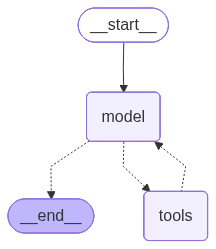

In [3]:
simple_worker = create_agent(
    model="google_genai:gemini-3.1-flash-lite",
    tools=[search, send_push_notification, wikipedia_lookup],
    system_prompt="You are Sidekick, a helpful personal assistant. Use your tools to complete the task.",
    checkpointer=InMemorySaver(),
)

simple_worker

In [4]:
async def ask(worker, message):
    config = {"configurable": {"thread_id": "simple-sidekick"}}
    result = await worker.ainvoke({"messages": [{"role": "user", "content": message}]}, config=config)
    return result["messages"][-1].content

reply = await ask(simple_worker, "Search for who won the Nobel Prize in Physics in 2023 and send a push notification with a short summary.")
print(reply)

[{'type': 'text', 'text': "The 2023 Nobel Prize in Physics was awarded to Pierre Agostini, Ferenc Krausz, and Anne L'Huillier for their experimental methods that generate attosecond pulses of light for the study of electron dynamics in matter. I have sent this summary to your phone as a push notification.", 'extras': {'signature': 'EjQKMgERTTIPOtKdY6kWTMEYqeJnUNqnyeaO0qgxWrXi5+smPvcBv5Bq/ISIhuU/h9gFf3SW'}}]


## Step 2: human-in-the-loop with middleware

LangChain supports allowing the agent to pause to collect feedback from a user. We tell `HumanInTheLoopMiddleware` which tools to pause on, and the agent stops and waits for our decision instead of running them.

When the agent reaches such a tool, the run pauses and returns an interrupt that describes the pending action. We can then approve, edit, reject, or respond, and resume.

In [5]:
from langchain_core.tools import tool

@tool
def book_meeting(person: str, day: str) -> str:
    """Book a meeting with a person on a given day."""
    return f"Meeting booked with {person} on {day}."

approval_agent = create_agent(
    model="google_genai:gemini-3.1-flash-lite",
    tools=[book_meeting],
    system_prompt="You are a scheduling assistant. Use the book_meeting tool.",
    middleware=[HumanInTheLoopMiddleware(interrupt_on={"book_meeting": True})],
    checkpointer=InMemorySaver(),
)

config = {"configurable": {"thread_id": "approval-demo"}}
result = await approval_agent.ainvoke(
    {"messages": [{"role": "user", "content": "Book a meeting with Sam on Friday."}]}, config
)

interrupt = result["__interrupt__"][0]
print("The agent paused and is asking for approval:")
print(interrupt.value["action_requests"][0]["description"])

The agent paused and is asking for approval:
Tool execution requires approval

Tool: book_meeting
Args: {'day': 'Friday', 'person': 'Sam'}


The agent is waiting. We approve the action, and the run continues from exactly where it paused.

Hold this thought: the full Sidekick uses this same middleware to gate its push notifications, and to power a `request_human_help` tool that lets the agent ask YOU to do something in its browser window, like logging in to a site, and carry on once you have done it.

In [6]:
resumed = await approval_agent.ainvoke(Command(resume={"decisions": [{"type": "approve"}]}), config)
print(resumed["messages"][-1].content)

[{'type': 'text', 'text': "OK. I've booked a meeting with Sam for this Friday.", 'extras': {'signature': 'EjQKMgERTTIPnn/pLDVz86bXDJmPz8lw99SETsiZK+NsELR9SkR73HC/3IZcUEnlnLLHrUmh'}}]


## Choosing how to respond

We approved that booking, but approve is only one of the choices. Your resume carries one decision per paused tool call, and each decision can be one of three kinds:

- **Approve** runs the tool exactly as proposed: `{"type": "approve"}`.
- **Edit** runs it, but with arguments you change first: `{"type": "edit", "edited_action": {"name": "book_meeting", "args": {"person": "Sam", "day": "Monday"}}}`.
- **Reject** skips the tool and hands a note back to the model so it can try another way: `{"type": "reject", "message": "No meetings on Fridays"}`.

So to decline the booking rather than approve it, you would resume like this instead:

```python
await approval_agent.ainvoke(
    Command(resume={"decisions": [{"type": "reject", "message": "No meetings on Fridays"}]}), config
)
```

You decide which of these a tool allows when you configure the middleware: `interrupt_on={"book_meeting": True}` permits all three, while `{"book_meeting": {"allowed_decisions": ["approve", "reject"]}}` would offer approve or reject but no editing. The Sidekick keeps things to plain approval, but edit and reject are the same one line of resume away.

In [7]:
config = {"configurable": {"thread_id": "rejection-demo2"}}
result = await approval_agent.ainvoke(
    {"messages": [{"role": "user", "content": "Book a meeting with Sam on Friday."}]}, config
)

interrupt = result["__interrupt__"][0]
print("The agent paused and is asking for approval:")
print(interrupt.value["action_requests"][0]["description"])

The agent paused and is asking for approval:
Tool execution requires approval

Tool: book_meeting
Args: {'person': 'Sam', 'day': 'Friday'}


In [8]:
resumed = await approval_agent.ainvoke(Command(resume={"decisions": [{"type": "reject", "message": "Rejected - no meetings on Fridays"}]}), config)
print(resumed["messages"][-1].content)

[{'type': 'text', 'text': "I'm sorry, but I'm unable to book a meeting with Sam on Friday because no meetings are allowed on that day. Would you like to schedule it for a different day instead?", 'extras': {'signature': 'EjQKMgERTTIPFJlPkV5qlRW5sOclWvhG1l/Jl4V9FYDyh0bYigLfmuhHX7C8/gNhlo7yBFVh'}}]


## Step 3: the full Sidekick

The complete version lives in `sidekick.py` and `sidekick_tools.py`. The worker has the full toolkit: a headed browser and a sandbox filesystem through persistent MCP sessions, plus web search, Wikipedia, push notifications and `request_human_help`. The middleware stack from the start of this lab is all in place, and the evaluator loop checks each answer against your success criteria, using the worker's tool calls as evidence, sending the worker back to try again when needed.

This is the whole stack in one object. The worker is a Layer 3 create_agent, its tools are Layer 1 `@tool` functions alongside MCP servers, its memory is a Layer 2 checkpointer, and the loop around it is code you wrote yourself. You chose the altitude for each part.

Let us bring one to life and start with a quick browser errand. Watch the window open and drive itself. The top story on Hacker News changes through the day, so you will see a different headline than the one shown here.

In [9]:
sidekick = Sidekick()
await sidekick.setup()
print(f"Sidekick ready with {len(sidekick.tools)} tools")

Sidekick ready with 42 tools


In [10]:
sidekick.tools

[GoogleSerperRun(api_wrapper=GoogleSerperAPIWrapper(k=10, gl='us', hl='en', type='search', result_key_for_type={'news': 'news', 'places': 'places', 'images': 'images', 'search': 'organic'}, tbs=None, serper_api_key='3ee355b85fb19edffdc772881c9c2f3b2b97c15e', aiosession=None)),
 StructuredTool(name='send_push_notification', description="Send a short push notification to the user's phone.", args_schema=<class 'langchain_core.utils.pydantic.send_push_notification'>, func=<function send_push_notification at 0x10e0916c0>),
 WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from '/Users/as-mac-1214/Desktop/projects/agents/.venv/lib/python3.12/site-packages/wikipedia/__init__.py'>, top_k_results=3, lang='en', load_all_available_meta=False, doc_content_chars_max=4000)),
 StructuredTool(name='request_human_help', description='Ask the user to do something in the browser window that you cannot do yourself,\n    such as logging in to a site, passing a captcha, or ap

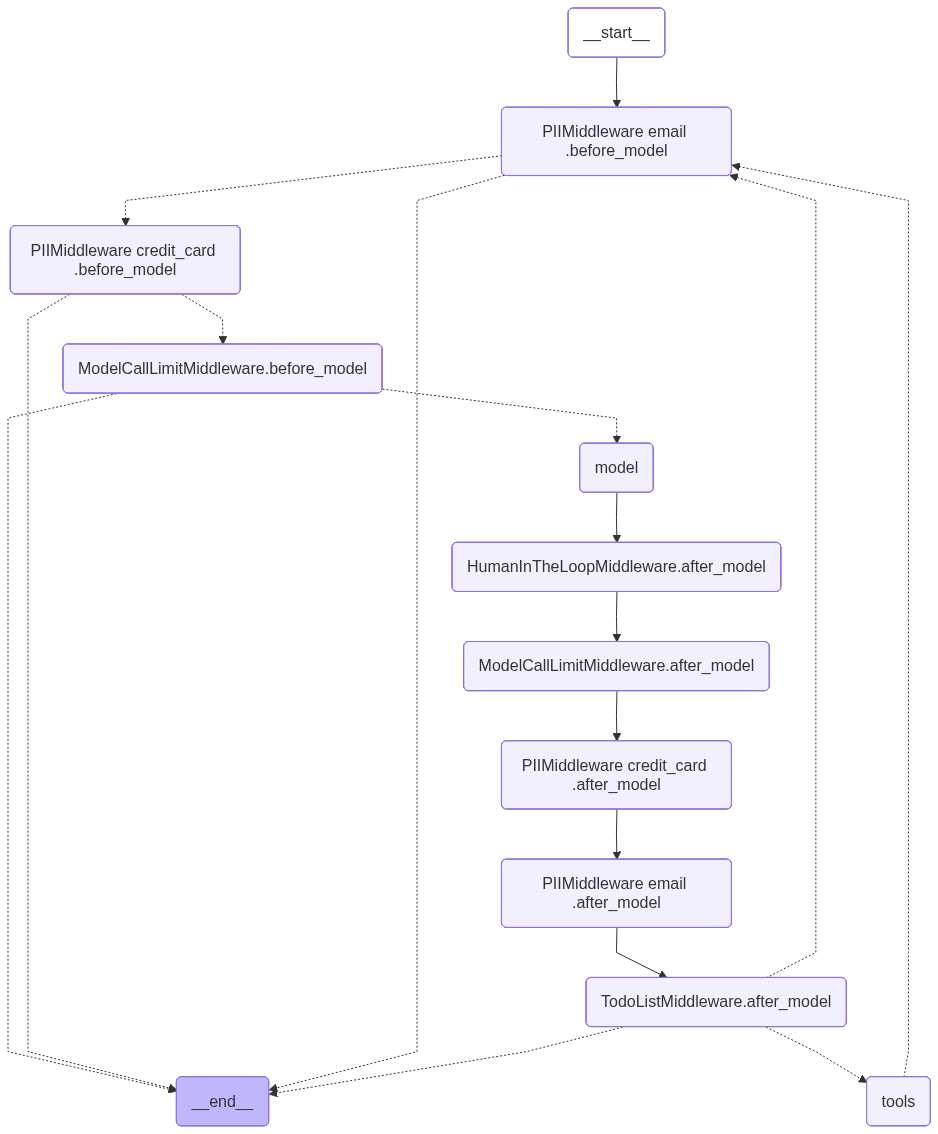

In [11]:
from langchain_core.runnables.graph_mermaid import draw_mermaid_png
from IPython.display import Image
mm = sidekick.worker.get_graph().draw_mermaid().replace("[", " ").replace("]", " ")
Image(draw_mermaid_png(mm, output_file_path="graph.png"))

In [12]:
history = await sidekick.run_turn(
    message="Go to Hacker News at news.ycombinator.com and tell me the title of the current top story.",
    success_criteria="The reply names a specific story currently on the Hacker News front page.",
    history=[],
)
for entry in history:
    print(f"[{entry['role']}] {entry['content'][:200]}\n")

Key '$schema' is not supported in schema, ignoring
Key 'additionalProperties' is not supported in schema, ignoring
Key '$schema' is not supported in schema, ignoring
Key 'additionalProperties' is not supported in schema, ignoring
Key '$schema' is not supported in schema, ignoring
Key 'additionalProperties' is not supported in schema, ignoring
Key '$schema' is not supported in schema, ignoring
Key 'additionalProperties' is not supported in schema, ignoring
Key '$schema' is not supported in schema, ignoring
Key 'additionalProperties' is not supported in schema, ignoring
Key '$schema' is not supported in schema, ignoring
Key 'additionalProperties' is not supported in schema, ignoring
Key '$schema' is not supported in schema, ignoring
Key 'additionalProperties' is not supported in schema, ignoring
Key '$schema' is not supported in schema, ignoring
Key 'additionalProperties' is not supported in schema, ignoring
Key '$schema' is not supported in schema, ignoring
Key 'additionalProperties' is

[user] Go to Hacker News at news.ycombinator.com and tell me the title of the current top story.

[assistant] [{'type': 'text', 'text': 'The current top story on Hacker News is titled: **"Jurassic Park computers in excruciating detail"**.', 'extras': {'signature': 'EjQKMgERTTIP4bYyGrmdkDHy+Xys3BZCOeEGCCwmDAKL/QT5VtxQHpbCESxAYVDr9iknLulr'}}]

[assistant] Evaluator: The assistant correctly used the provided tools to access Hacker News and successfully identified the current top story.



## The finale: a real errand

Now a task worthy of the week: find me the best flight. This needs a plan, a stretch of real browsing, a file, and a push notification, and it ends with the Sidekick asking your permission. One detail to notice in `sidekick.py`: the worker's system prompt carries a practical trick, that Google Flights accepts a natural language query straight in the URL, giving your agent specialist abilities.

While it works, watch the browser window, and peek at the plan: the worker maintains a todo list through its `write_todos` tool, and the Sidekick exposes it as `sidekick.todos`.

In [13]:
flight_task = """Find me the best round-trip flight from New York to London, leaving about a month from now
and returning a week later. I care about price first, then total journey time, and I would rather avoid
itineraries with two or more stops. Write your recommendation with the top three options to flights.md,
then send me a push notification with the price of your top pick."""

flight_criteria = "flights.md is written with three specific options including airline, times and price, plus a clear recommendation, and a push notification was sent with the recommended price."

history = await sidekick.run_turn(flight_task, flight_criteria, history)
print(history[-1]["content"])

Key '$schema' is not supported in schema, ignoring
Key 'additionalProperties' is not supported in schema, ignoring
Key '$schema' is not supported in schema, ignoring
Key 'additionalProperties' is not supported in schema, ignoring
Key '$schema' is not supported in schema, ignoring
Key 'additionalProperties' is not supported in schema, ignoring
Key '$schema' is not supported in schema, ignoring
Key 'additionalProperties' is not supported in schema, ignoring
Key '$schema' is not supported in schema, ignoring
Key 'additionalProperties' is not supported in schema, ignoring
Key '$schema' is not supported in schema, ignoring
Key 'additionalProperties' is not supported in schema, ignoring
Key '$schema' is not supported in schema, ignoring
Key 'additionalProperties' is not supported in schema, ignoring
Key '$schema' is not supported in schema, ignoring
Key 'additionalProperties' is not supported in schema, ignoring
Key '$schema' is not supported in schema, ignoring
Key 'additionalProperties' is

Waiting for your approval:
Tool execution requires approval

Tool: send_push_notification
Args: {'text': 'The best round-trip flight from New York to London (Aug 15-22) is ₹74,301. Details are in flights.md.'}


The Sidekick has done the work, and now it is paused, asking permission to send the notification. Its plan tells the story:

In [14]:
for todo in sidekick.todos:
    print(f"[{todo['status']}] {todo['content']}")

[in_progress] Search for flights from New York to London (Aug 15 to Aug 22, 2026) on Google Flights
[pending] Identify top three options based on price and duration (avoiding 2+ stops)
[pending] Write the top three options and recommendation to flights.md
[pending] Send a push notification with the top pick price


We approve, the notification arrives on your phone, and the evaluator confirms the criteria were met, with the tool calls as its evidence.

In [15]:
if sidekick.paused:
    history = await sidekick.resume(history)
for entry in history[-2:]:
    print(f"[{entry['role']}] {entry['content']}\n")

Key '$schema' is not supported in schema, ignoring
Key 'additionalProperties' is not supported in schema, ignoring
Key '$schema' is not supported in schema, ignoring
Key 'additionalProperties' is not supported in schema, ignoring
Key '$schema' is not supported in schema, ignoring
Key 'additionalProperties' is not supported in schema, ignoring
Key '$schema' is not supported in schema, ignoring
Key 'additionalProperties' is not supported in schema, ignoring
Key '$schema' is not supported in schema, ignoring
Key 'additionalProperties' is not supported in schema, ignoring
Key '$schema' is not supported in schema, ignoring
Key 'additionalProperties' is not supported in schema, ignoring
Key '$schema' is not supported in schema, ignoring
Key 'additionalProperties' is not supported in schema, ignoring
Key '$schema' is not supported in schema, ignoring
Key 'additionalProperties' is not supported in schema, ignoring
Key '$schema' is not supported in schema, ignoring
Key 'additionalProperties' is

[assistant] [{'type': 'text', 'text': 'I have completed your request regarding the flights from New York to London (August 15th to August 22nd, 2026).\n\nI searched Google Flights and identified three nonstop options. These, along with my recommendation, have been saved to `flights.md`. I also sent a push notification to your device with the price of the top pick.', 'extras': {'signature': 'EjQKMgERTTIPhXDHXZWYKPVmqT3L7vasozl1q2xooheD3a/eWK97Zn6jFRiLlQqh6/5j6Dm1'}}]

[assistant] Evaluator: The assistant correctly searched for flights, wrote the three options to the specified file, and sent the required push notification. The process followed the workflow described in the tool calls.



## The Gradio app

`app.py` wraps all of this in a chat interface: a request box, a success criteria box, the Sidekick's plan updating live beside the chat while it works, and an Approve button that appears whenever it pauses for your say-so. Reset really does close the browser now, since the persistent MCP sessions shut down cleanly.

The look and feel lives in `styles.py` as a theme, a CSS constant and a JS constant. A Gradio 6 note: these are passed to `launch()`, not to `gr.Blocks()` as in older Gradio. Run the app from a terminal with `uv run app.py`, or launch the very same interface right here:

In [ ]:
from app import ui, LAUNCH_STYLE

ui.launch(**LAUNCH_STYLE)

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


/Users/as-mac-1214/Desktop/projects/agents/.venv/lib/python3.12/site-packages/gradio/routes.py:1541: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/Users/as-mac-1214/Desktop/projects/agents/.venv/lib/python3.12/site-packages/gradio/routes.py:1541: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/Users/as-mac-1214/Desktop/projects/agents/.venv/lib/python3.12/site-packages/gradio/routes.py:1541: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/Users/as-mac-1214/Desktop/projects/agents/.venv/lib/python3.12/site-packages/gradio/routes.py:1541: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENT

<table style="margin: 0; text-align: left; width:100%">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/thanks.png" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#00cc00;">Congratulations</h2>
            <span style="color:#00cc00;">You have built the Sidekick, and with it you have travelled the whole stack: the building blocks of Layer 1, the orchestration of LangGraph, the create_agent of Layer 3, the harness of Deep Agents, and now a real project that mixes them all, with middleware for planning, guardrails and human approval. That is a serious amount of capability, and you understand every layer of it. Wonderful work this week.
            </span>
        </td>
    </tr>
</table>

<table style="margin: 0; text-align: left; width:100%">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/exercise.png" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#ff7800;">Exercise</h2>
            <span style="color:#ff7800;">Make the Sidekick truly yours. Start with a personal errand: try the Expedia version of the flight task, asking the Sidekick to sign in to your Expedia account first. When it reaches the login page it will call <code>request_human_help</code> and pause while you log in to its browser window, then press on with the search. Travel sites defend themselves against automation, so expect the occasional block wall; that is part of working with real-world agents. Then go further: gate the filesystem write tools behind the approval middleware in <code>sidekick.py</code>, add a tool of your own, and set the Sidekick a task you actually need done this week, with a clear success criterion.
            </span>
        </td>
    </tr>
</table>